In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import os

In [34]:
path = kagglehub.dataset_download("prince7489/mental-health-and-social-media-balance-dataset")
df = pd.read_csv(os.path.join(path, 'Mental_Health_and_Social_Media_Balance_Dataset.csv'))
#df = pd.read_csv('Mental_Health_and_Social_Media_Balance_Dataset.csv')

In [35]:
df.head()

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0


In [36]:
df.shape

(500, 10)

In [37]:
df.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time(hrs)',
       'Sleep_Quality(1-10)', 'Stress_Level(1-10)',
       'Days_Without_Social_Media', 'Exercise_Frequency(week)',
       'Social_Media_Platform', 'Happiness_Index(1-10)'],
      dtype='object')

In [38]:
### Determining if there are any NA values in the data set. 

df.isna().any().any() #confirmed there are no values of NA or Null

np.False_

In [39]:
# the data is almost exactly event for male vs. female. To be exact there are 19 more men than women. 

df['Gender'].value_counts()

Gender
Male      248
Female    229
Other      23
Name: count, dtype: int64

#### We might want to consider removing the rows with "other in the df if we are going to be using gender to determine happiness index

In [40]:
df.describe()

,Age,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Happiness_Index(1-10)
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,32.988000,5.530000,6.304000,6.618000,3.134000,2.448000,8.376000
std,9.960637,1.734877,1.529792,1.542996,1.858751,1.428067,1.524228
min,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,4.000000
25%,24.000000,4.300000,5.000000,6.000000,2.000000,1.000000,7.000000
50%,34.000000,5.600000,6.000000,7.000000,3.000000,2.000000,9.000000
75%,41.000000,6.700000,7.000000,8.000000,5.000000,3.000000,10.000000
max,49.000000,10.800000,10.000000,10.000000,9.000000,7.000000,10.000000


## Determine the distribution of the Social Media Platforms mentions/Used

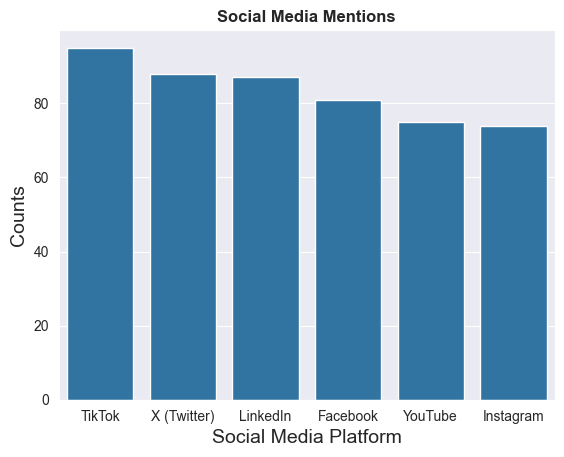

In [41]:
#determine the distribution of the Social Media Platforms mentions/Used

sm_df = df['Social_Media_Platform']

sm_counts = sm_df.value_counts().reset_index()
sm_counts.columns = ['Platform', 'Counts']
#print(sm_counts)

sns.barplot(data=sm_counts, x='Platform', y='Counts')

plt.title('Social Media Mentions', fontsize=12, fontweight='bold')
plt.xlabel('Social Media Platform', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.show()

## Distribution of the Age in the data

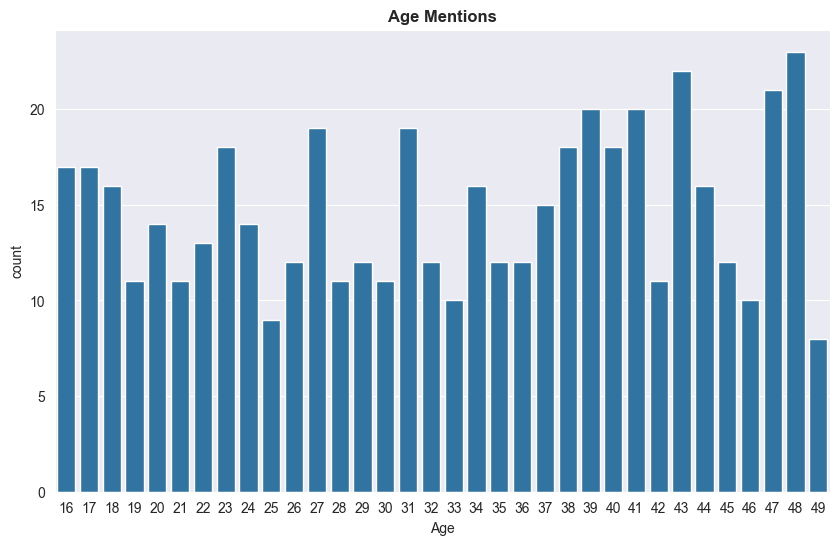

In [42]:
age_df = df['Age'].value_counts().reset_index()

#age_df.head()

plt.figure(figsize=(10, 6))

sns.barplot(data=age_df, x='Age', y='count')
plt.title('Age Mentions', fontsize='12', fontweight='bold')
plt.show()

## Distribution of the Screen Time Data

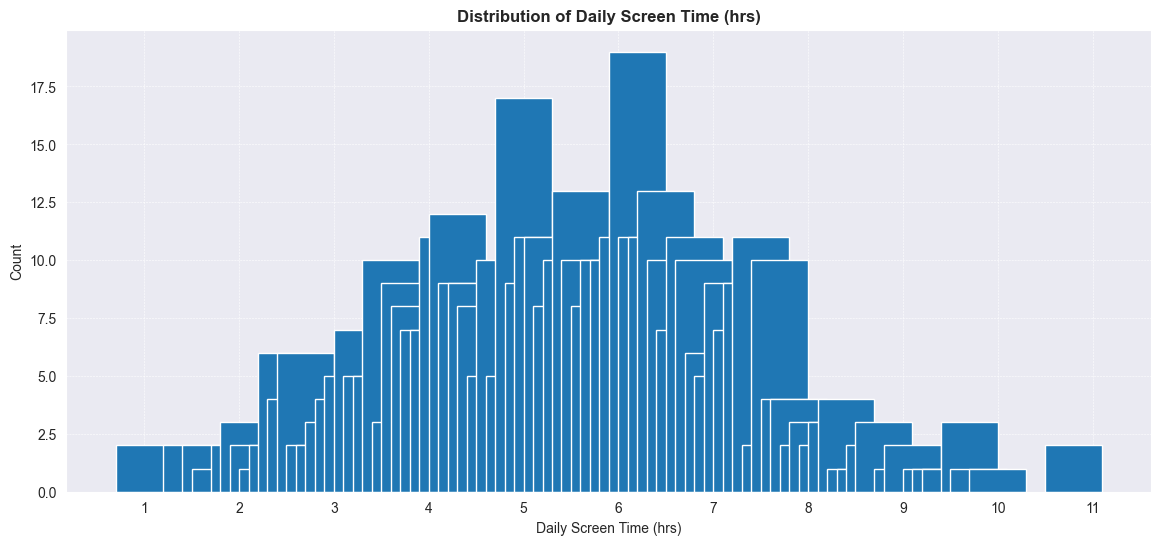

In [43]:
screen_df = df['Daily_Screen_Time(hrs)'].value_counts().reset_index()
screen_df.columns = ['Daily_Screen_Time(hrs)', 'count']

screen_df['Daily_Screen_Time(hrs)'] = pd.to_numeric(screen_df['Daily_Screen_Time(hrs)'], errors='coerce')

screen_df = screen_df.sort_values('Daily_Screen_Time(hrs)')

#print(screen_df)

plt.figure(figsize=(14,6))
plt.bar(screen_df['Daily_Screen_Time(hrs)'], screen_df['count'], width=0.6)

plt.xticks(np.arange(
    np.floor(screen_df['Daily_Screen_Time(hrs)'].min()),
    np.ceil(screen_df['Daily_Screen_Time(hrs)'].max()) + 0.5, 1))

plt.xlabel("Daily Screen Time (hrs)")
plt.ylabel("Count")
plt.title("Distribution of Daily Screen Time (hrs)", fontsize=12, fontweight='bold')
plt.grid(linestyle="--", linewidth='0.4')
plt.show()

## Distribution of the Stress Levels Data

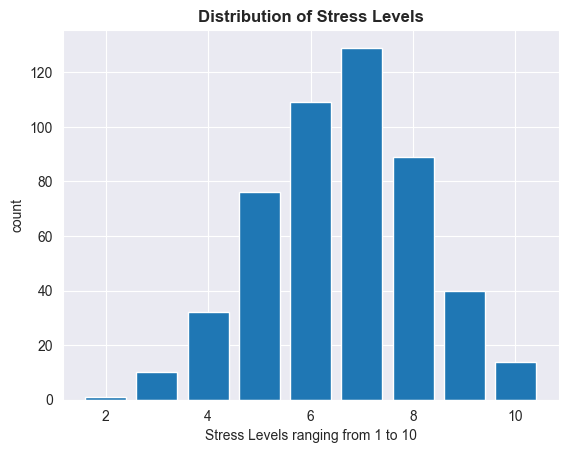

In [44]:
stress_df = df['Stress_Level(1-10)'].value_counts().reset_index()
stress_df = stress_df.sort_values('Stress_Level(1-10)')
#print(stress_df)

plt.bar(stress_df['Stress_Level(1-10)'], stress_df['count'])

plt.xlabel('Stress Levels ranging from 1 to 10')
plt.ylabel('count')
plt.title('Distribution of Stress Levels', fontsize=12, fontweight='bold')
plt.show()

## The Graph below will show the Happiness Index vs the Daily Screen Time. I also included the means for each happiness index.

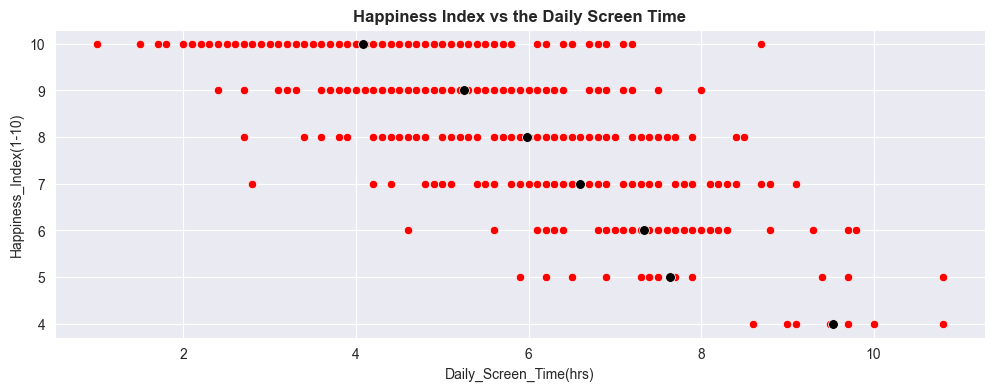

In [45]:
plt.figure(figsize=(12,4))

sns.scatterplot(data=df, x='Daily_Screen_Time(hrs)', y='Happiness_Index(1-10)', color='red')

mean_points = df.groupby('Happiness_Index(1-10)', as_index=False)['Daily_Screen_Time(hrs)'].mean()

sns.scatterplot(mean_points, x='Daily_Screen_Time(hrs)', y='Happiness_Index(1-10)', color='black', s=50)

plt.title('Happiness Index vs the Daily Screen Time', fontsize=12, fontweight='bold')

plt.show()

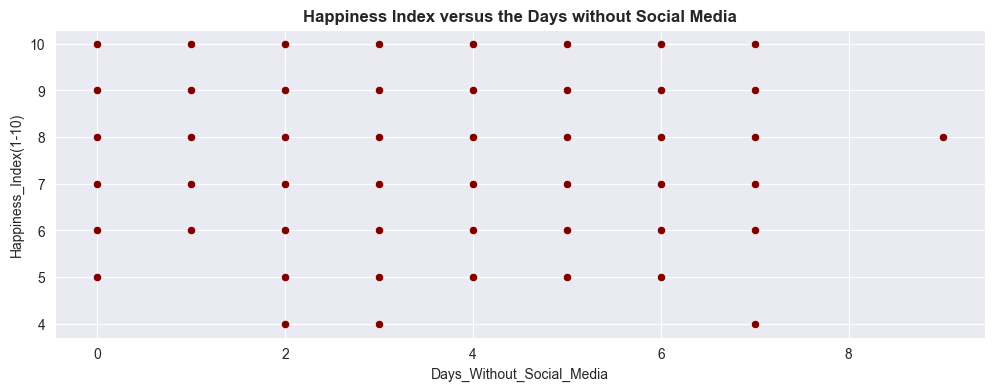

In [46]:
## The Figure below shows that there are almost always 0-7 days without social media in each happiness index from 5-10.
# We also know that the data set never mentions a happiness index under 4. 

plt.figure(figsize=(12,4))

sns.scatterplot(data=df, x='Days_Without_Social_Media', y='Happiness_Index(1-10)', color='maroon')

plt.title('Happiness Index versus the Days without Social Media', fontsize=12, fontweight='bold')
plt.show()

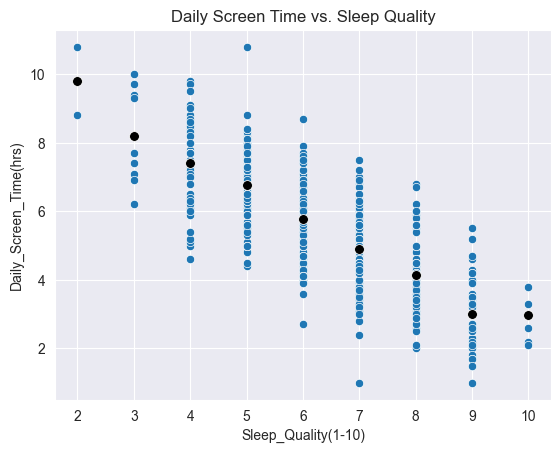

In [47]:
# viewing the data in resepect to screen time and Sleep Quality. It looks like the lower the screen time the higher reported sleep quality. 

mean_points=df.groupby('Sleep_Quality(1-10)', as_index=False)['Daily_Screen_Time(hrs)'].mean()

sns.scatterplot(data=df, x='Sleep_Quality(1-10)', y='Daily_Screen_Time(hrs)')
sns.scatterplot(mean_points, x='Sleep_Quality(1-10)', y='Daily_Screen_Time(hrs)', color='black', s=50)

plt.title('Daily Screen Time vs. Sleep Quality', fontsize=12)

plt.show()

## Visualizing if people over the age of 33 [which is the mean of the age] daily screen time and stress levels. 

In [48]:
over_33 = df[df['Age'] >= 33]
under_33 = df[df['Age'] < 33]

over_33.shape ## this is almost exactly half of the df

over_33.columns

Index(['User_ID', 'Age', 'Gender', 'Daily_Screen_Time(hrs)',
       'Sleep_Quality(1-10)', 'Stress_Level(1-10)',
       'Days_Without_Social_Media', 'Exercise_Frequency(week)',
       'Social_Media_Platform', 'Happiness_Index(1-10)'],
      dtype='object')

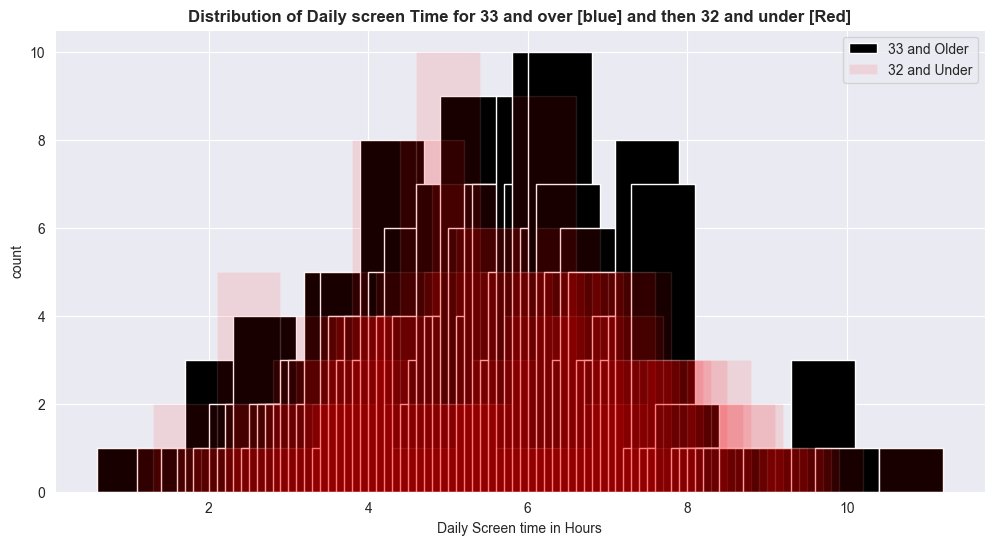

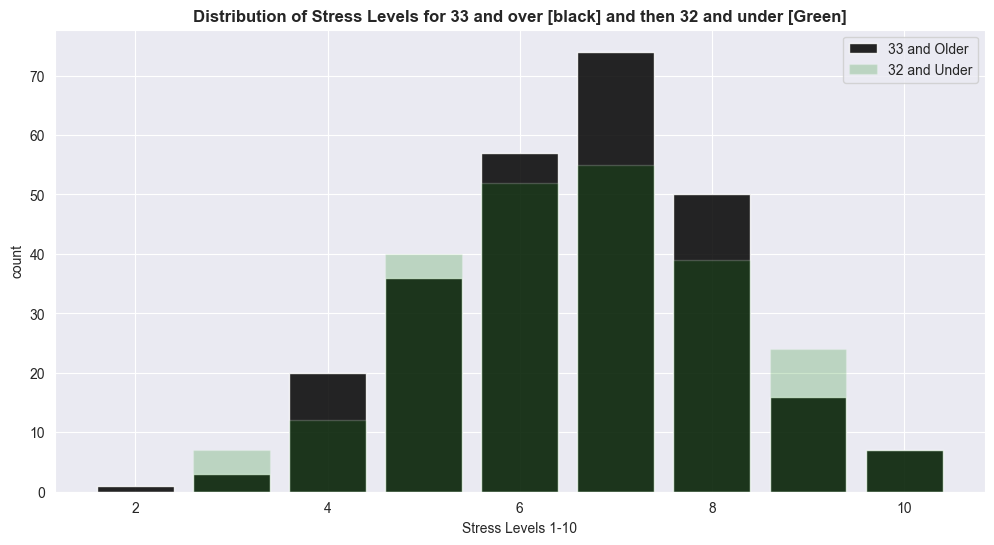

In [49]:
daily_screen = over_33['Daily_Screen_Time(hrs)'].value_counts().reset_index()
daily_screen = daily_screen.sort_values('Daily_Screen_Time(hrs)')

daily_screen_under = under_33['Daily_Screen_Time(hrs)'].value_counts().reset_index()
daily_screen_under = daily_screen_under.sort_values('Daily_Screen_Time(hrs)')

plt.figure(figsize=(12,6))
plt.bar(daily_screen['Daily_Screen_Time(hrs)'], daily_screen['count'], alpha=1, label='33 and Older', color='black')
plt.bar(daily_screen_under['Daily_Screen_Time(hrs)'], daily_screen_under['count'], color='red', alpha=0.1, label='32 and Under')

plt.title('Distribution of Daily screen Time for 33 and over [blue] and then 32 and under [Red]', fontsize=12, fontweight='bold')
plt.xlabel('Daily Screen time in Hours')
plt.ylabel('count')
plt.legend()
plt.show()


daily_stress = over_33['Stress_Level(1-10)'].value_counts().reset_index()
daily_stress = daily_stress.sort_values('Stress_Level(1-10)')

daily_stress_under = under_33['Stress_Level(1-10)'].value_counts().reset_index()
daily_stress_under = daily_stress_under.sort_values('Stress_Level(1-10)')

plt.figure(figsize=(12,6))
plt.bar(daily_stress['Stress_Level(1-10)'], daily_stress['count'], alpha=0.85, label='33 and Older', color='black')
plt.bar(daily_stress_under['Stress_Level(1-10)'], daily_stress_under['count'], color='green', alpha=0.2, label='32 and Under')

plt.title('Distribution of Stress Levels for 33 and over [black] and then 32 and under [Green]', fontsize=12, fontweight='bold')
plt.xlabel('Stress Levels 1-10')
plt.ylabel('count')
plt.legend()
plt.show()

## 1) How does the daily screen time and social media platform affect the Happiness index of the users? 

In [50]:
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
import statsmodels.formula.api as smf

In [51]:
df_1 = df[['Daily_Screen_Time(hrs)','Social_Media_Platform', 'Happiness_Index(1-10)']]

#encoding the datas
df_encoded = pd.get_dummies(df_1, columns=['Social_Media_Platform'], drop_first=True)

df_encoded.head()

#define the variables
X_1 = df_encoded.drop('Happiness_Index(1-10)', axis=1)
y_1 = df_encoded['Happiness_Index(1-10)']

#adding the constant variable
X_1 = sm.add_constant(X_1)

#print(X_1)

#linearRegression
model = LinearRegression()
model.fit(X_1, y_1)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
coefficients = pd.Series(model.coef_, index=X_1.columns)
intercept = model.intercept_

In [53]:
print(coefficients)
print(intercept)

const                                0.000000
Daily_Screen_Time(hrs)              -0.617333
Social_Media_Platform_Instagram     -0.098860
Social_Media_Platform_LinkedIn      -0.054425
Social_Media_Platform_TikTok        -0.090278
Social_Media_Platform_X (Twitter)    0.085237
Social_Media_Platform_YouTube       -0.149736
dtype: float64
11.838564736111168


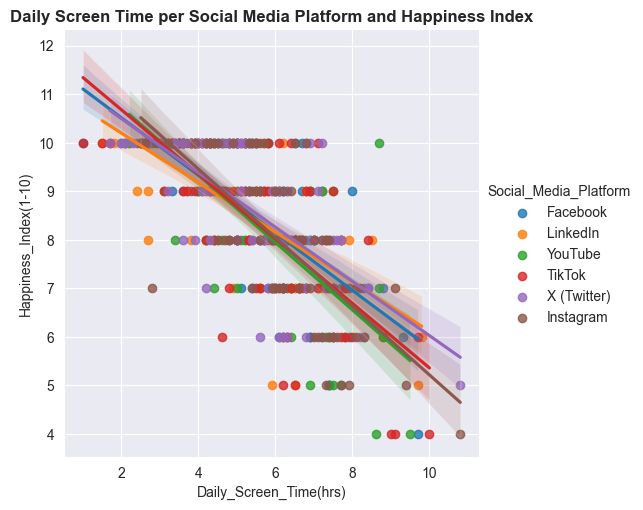

In [54]:
sns.lmplot(data=df_1, x='Daily_Screen_Time(hrs)', y='Happiness_Index(1-10)', hue='Social_Media_Platform')

plt.title('Daily Screen Time per Social Media Platform and Happiness Index', fontsize=12, fontweight='bold')
plt.show()

In [55]:
model = smf.ols('Q("Happiness_Index(1-10)") ~ Q("Daily_Screen_Time(hrs)") * C(Social_Media_Platform)', data=df_1).fit()
model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                                OLS Regression Results                                
======================================================================================
Dep. Variable:     Q("Happiness_Index(1-10)")   R-squared:                       0.506
Model:                                    OLS   Adj. R-squared:                  0.495
Method:                         Least Squares   F-statistic:                     45.48
Date:                        Sun, 23 Nov 2025   Prob (F-statistic):           8.92e-68
Time:                                20:24:02   Log-Likelihood:                -743.31
No. Observations:                         500   AIC:                             1511.
Df Residuals:                             488   BIC:                             1561.
Df Model:                                  11                                         
Covariance Type:                    nonrobust                                         
=======================================================================================================================================
                                                                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                              11.6978      0.407     28.763      0.000      10.899      12.497
C(Social_Media_Platform)[T.Instagram]                                   0.5833      0.636      0.917      0.359      -0.666       1.833
C(Social_Media_Platform)[T.LinkedIn]                                   -0.4820      0.560     -0.860      0.390      -1.583       0.619
C(Social_Media_Platform)[T.TikTok]                                      0.3080      0.546      0.564      0.573      -0.766       1.382
C(Social_Media_Platform)[T.X (Twitter)]                                -0.0865      0.549     -0.158      0.875      -1.165       0.991
C(Social_Media_Platform)[T.YouTube]                                     0.4157      0.582      0.714      0.476      -0.729       1.560
Q("Daily_Screen_Time(hrs)")                                            -0.5925      0.069     -8.629      0.000      -0.727      -0.458
Q("Daily_Screen_Time(hrs)"):C(Social_Media_Platform)[T.Instagram]      -0.1139      0.104     -1.099      0.272      -0.318       0.090
Q("Daily_Screen_Time(hrs)"):C(Social_Media_Platform)[T.LinkedIn]        0.0825      0.098      0.845      0.399      -0.109       0.274
Q("Daily_Screen_Time(hrs)"):C(Social_Media_Platform)[T.TikTok]         -0.0721      0.094     -0.769      0.442      -0.256       0.112
Q("Daily_Screen_Time(hrs)"):C(Social_Media_Platform)[T.X (Twitter)]     0.0340      0.095      0.357      0.721      -0.153       0.221
Q("Daily_Screen_Time(hrs)"):C(Social_Media_Platform)[T.YouTube]        -0.1024      0.100     -1.025      0.306      -0.299       0.094
==============================================================================
Omnibus:                        3.386   Durbin-Watson:                   2.113
Prob(Omnibus):                  0.184   Jarque-Bera (JB):                3.157
Skew:                          -0.175   Prob(JB):                        0.206
Kurtosis:                       3.170   Cond. No.                         140.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

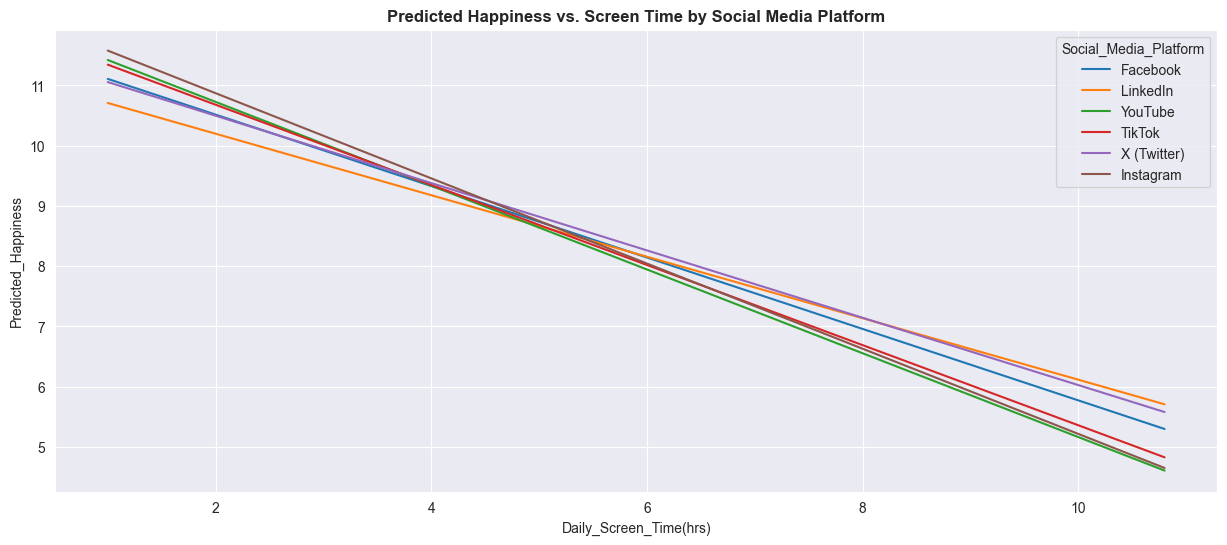

In [56]:
screen_time_range = np.linspace(df_1['Daily_Screen_Time(hrs)'].min(), df_1['Daily_Screen_Time(hrs)'].max(), 100)

platforms = df_1['Social_Media_Platform'].unique()

pred_dfs = []
for p in platforms:
    temp_df = pd.DataFrame({'Daily_Screen_Time(hrs)': screen_time_range, 'Social_Media_Platform': p})
    temp_df['Predicted_Happiness'] = model.predict(temp_df)
    pred_dfs.append(temp_df)

pred_dfs = pd.concat(pred_dfs)

plt.figure(figsize=(15,6))

#sns.scatterplot(data=df_1, x='Daily_Screen_Time(hrs)', y='Happiness_Index(1-10)', hue='Social_Media_Platform')

sns.lineplot(data=pred_dfs, x='Daily_Screen_Time(hrs)', y='Predicted_Happiness', hue='Social_Media_Platform')
plt.title('Predicted Happiness vs. Screen Time by Social Media Platform', fontsize=12, fontweight='bold')
plt.show()

## 2. How does lifestyle affect the happiness index of the users? Do people with more unhealthy lifestyles [such as higher stress levels, low sleep quality, and low exercise frequency affect the happiness index of a user? 